/kaggle/input/teta-ml-1-2025

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [ ]:
yes_no_colors = ['#FF6E6E', '#7EFD5E']
background_color = '#041744'


fill_color = "#491bbf"
font_style = 'serif'
font_color = '#FDE2FF'

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['axes.labelcolor'] = font_color
plt.rcParams['axes.edgecolor'] = font_color
plt.rcParams['font.family'] = font_style
plt.rcParams['text.color'] = font_color
plt.rcParams['xtick.color'] = font_color
plt.rcParams['ytick.color'] = font_color

### Итоговый результат

In [ ]:
print("we are goood")

we are goood


Итог: модель CatBoostRegressor показала самый лучший результат mse 1400~ на трейне и 1230 на тесте. Брала катбуст потому что есть категориальные признаки, которые имеют значение

1. **Как обработала данные:** для начала посмотрела на пропуски в данных и заметила что NaN в last_dt и agv_reviews стоят там, где amt_reviews == 0. Поэтому признак даты я заменила на бинарный "visited", где 1 - посещено, 0 - не посещено. (если нет отзывов ставим 0).  А пропуски в avg_reviews где amt_reviews==0 заполнила нулями (тут просто не из чего даже среднее считать будет 🥲). Так же решила отскейлить данные, в надежде на то, что тогда обучение будет идти лучше
2. **Итоговый алгоритм:** лучше всего получился CatBoostRegressor. Почему он? Есть категориальные признаки (host_name, location, location_cluster) и катбуст сам их очень хорошо обрабатывает, поэтому выбран он как итоговый.
3. **Параметры следующие:**


```
model = CatBoostRegressor(
    iterations=1187,
    depth=6,
    learning_rate=0.04073705914148531,
    border_count = 136,
    verbose=200
)
```

параметры подбирала с помощью optuna и эти выдали достойный результат на трейне и на тесте.

4. Использовала кросс - валидацию, тк с ней лучше можно оценить стабильность модели


### Считали данные

In [ ]:
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [ ]:
print(df_train.shape)
print(df_test.shape)

(36671, 15)
(12224, 14)


In [ ]:
df_train.head(5)

,name,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2019-07-07,2.88,1,334
1,"Come see Brooklyn, New York",13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,2015-02-25,0.13,1,0
2,Large 2Br on W71st & Columbus Feb 19-28,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,NaN,1,0
3,Perfect bedroom. Near Subways Columbia CityCol...,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,2018-11-04,0.64,1,0
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,2019-06-23,0.76,1,155


In [ ]:
df_train.isna().sum()

,0
name,9
_id,0
host_name,18
location_cluster,0
location,0
lat,0
lon,0
type_house,0
sum,0
min_days,0


In [ ]:
df_test.isna().sum()

,0
name,7
_id,0
host_name,3
location_cluster,0
location,0
lat,0
lon,0
type_house,0
sum,0
min_days,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36671 entries, 0 to 36670
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              36662 non-null  object 
 1   _id               36671 non-null  int64  
 2   host_name         36653 non-null  object 
 3   location_cluster  36671 non-null  object 
 4   location          36671 non-null  object 
 5   lat               36671 non-null  float64
 6   lon               36671 non-null  float64
 7   type_house        36671 non-null  object 
 8   sum               36671 non-null  int64  
 9   min_days          36671 non-null  int64  
 10  amt_reviews       36671 non-null  int64  
 11  last_dt           29169 non-null  object 
 12  avg_reviews       29169 non-null  float64
 13  total_host        36671 non-null  int64  
 14  target            36671 non-null  int64  
dtypes: float64(3), int64(6), object(6)
memory usage: 4.2+ MB


# Начинаем страдания обработки

In [ ]:
categorical_columns = df_train.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index(['name', 'host_name', 'location_cluster', 'location', 'type_house',
       'last_dt'],
      dtype='object')

In [ ]:
df_train.drop(columns=['name'], inplace=True, errors='ignore')
df_test.drop(columns=['name'], inplace=True, errors='ignore')

In [ ]:
numerical_columns = df_train.select_dtypes(include=['int64', 'float64']).columns
numerical_columns

Index(['_id', 'lat', 'lon', 'sum', 'min_days', 'amt_reviews', 'avg_reviews',
       'total_host', 'target'],
      dtype='object')

In [ ]:
df_train['target'].min()

0

<Axes: xlabel='target', ylabel='Density'>

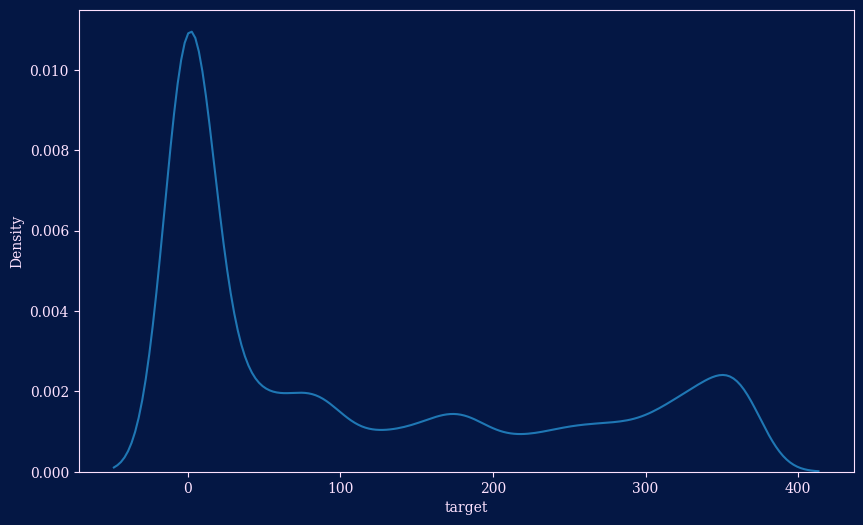

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['target'])

In [ ]:
types_house = df_train['type_house'].unique()
types_house

array(['Entire home/apt', 'Shared room', 'Private room'], dtype=object)

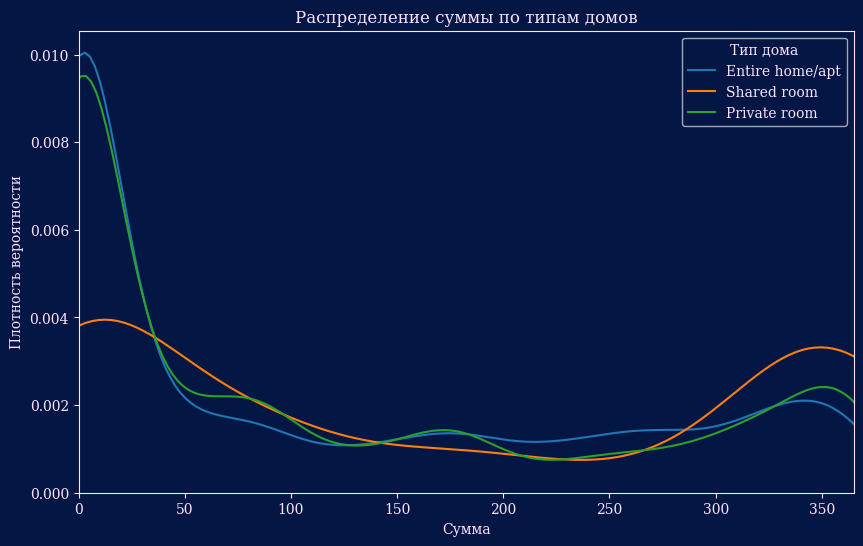

In [ ]:
plt.figure(figsize=(10, 6))

for house_type in types_house:
    sns.kdeplot(df_train[df_train['type_house'] == house_type]['target'], label=house_type)

plt.title('Распределение суммы по типам домов')
plt.xlim(0, df_train['target'].max())
plt.xlabel('Сумма')
plt.ylabel('Плотность вероятности')
plt.legend(title='Тип дома')
plt.show()

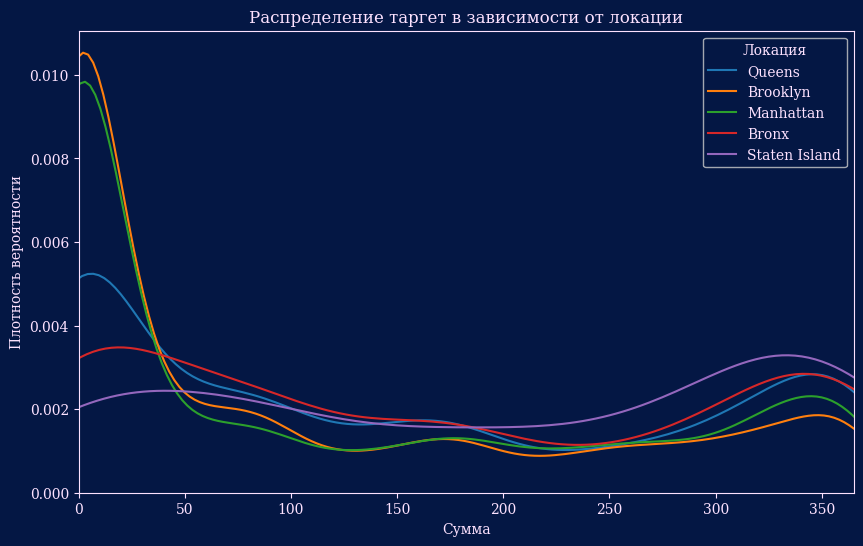

In [ ]:
plt.figure(figsize=(10, 6))

clusters = df_train['location_cluster'].unique()
for cluster in clusters:
    sns.kdeplot(df_train[df_train['location_cluster'] == cluster]['target'], label=cluster)

plt.title('Распределение таргет в зависимости от локации')
plt.xlim(0, df_train['target'].max())
plt.xlabel('Сумма')
plt.ylabel('Плотность вероятности')
plt.legend(title='Локация')
plt.show()

In [ ]:
df_train.columns

Index(['_id', 'host_name', 'location_cluster', 'location', 'lat', 'lon',
       'type_house', 'sum', 'min_days', 'amt_reviews', 'last_dt',
       'avg_reviews', 'total_host', 'target'],
      dtype='object')

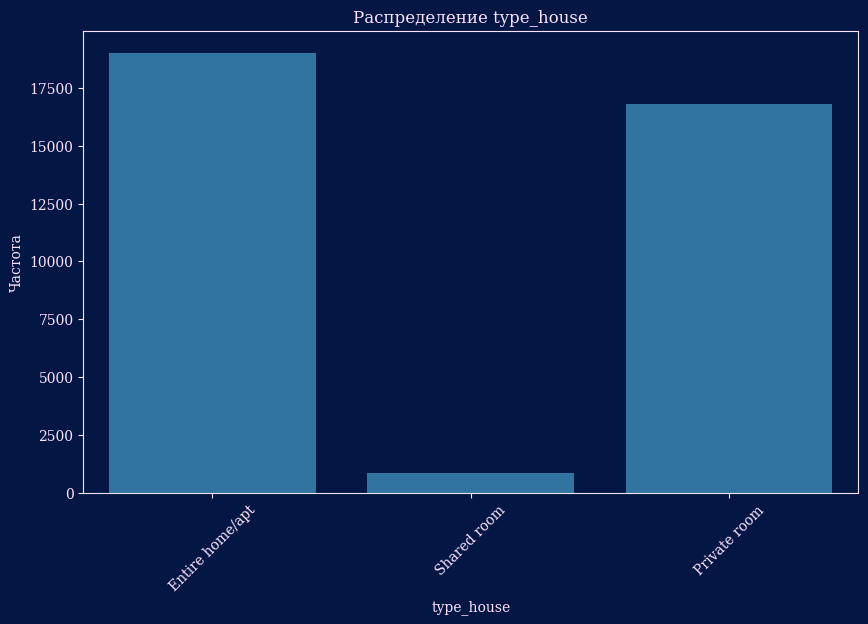

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='type_house',)
plt.xticks(rotation=45)
plt.title('Распределение type_house')
plt.xlabel('type_house')
plt.ylabel('Частота')
plt.show()


#### Развлекаемся с пропусками отзывов

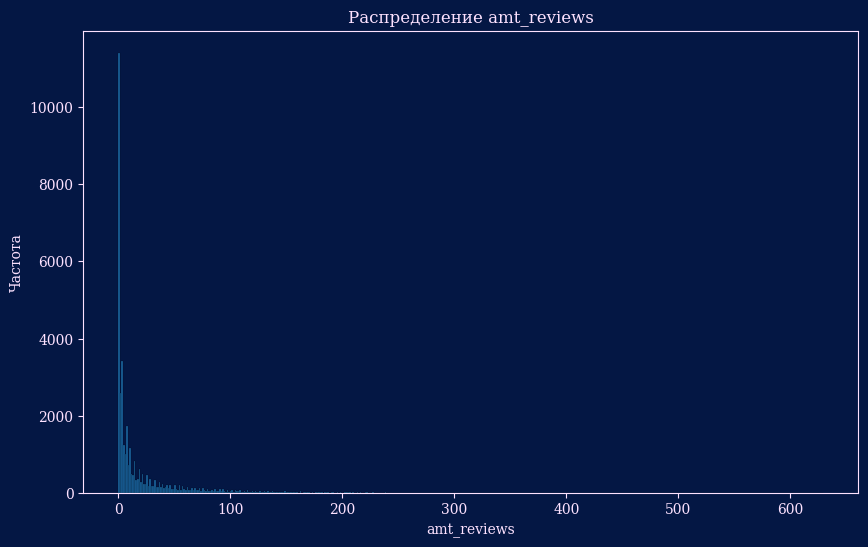

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_train['amt_reviews'])
plt.title('Распределение amt_reviews')
plt.xlabel('amt_reviews')
plt.ylabel('Частота')
plt.show()

In [ ]:
df_train['avg_reviews'] = df_train.apply(
    lambda row: 0 if (pd.isna(row['avg_reviews']) and row['amt_reviews'] == 0) else row['avg_reviews'], axis=1)

df_test['avg_reviews'] = df_test.apply(
    lambda row: 0 if (pd.isna(row['avg_reviews']) and row['amt_reviews'] == 0) else row['avg_reviews'], axis=1)


In [ ]:
df_test.isna().sum()

,0
_id,0
host_name,3
location_cluster,0
location,0
lat,0
lon,0
type_house,0
sum,0
min_days,0
amt_reviews,0


вышло просто бомбезно

#### Пропуски даты

In [ ]:
missed_last_dt = df_train[df_train['last_dt'].isna()]
missed_last_dt

,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
2,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,0.0,1,0
8,19529891,Shilpa,Manhattan,Upper East Side,40.76870,-73.95560,Entire home/apt,135,3,0,NaN,0.0,1,0
16,1818225,Amael,Brooklyn,Greenpoint,40.72212,-73.93780,Entire home/apt,80,3,0,NaN,0.0,1,0
22,156114168,Kateryna,Brooklyn,Prospect-Lefferts Gardens,40.66049,-73.96162,Shared room,40,1,0,NaN,0.0,6,211
28,146944,David,Manhattan,East Village,40.72807,-73.98594,Entire home/apt,200,3,0,NaN,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36651,200380610,Pranjal,Manhattan,Midtown,40.75237,-73.97040,Entire home/apt,190,30,0,NaN,0.0,65,364
36652,157056254,Rae,Brooklyn,Bushwick,40.70312,-73.91933,Private room,45,7,0,NaN,0.0,1,0
36653,2676750,Shayna,Manhattan,Financial District,40.70789,-74.01521,Private room,90,3,0,NaN,0.0,1,0
36658,24298733,Tuva,Brooklyn,Kensington,40.63670,-73.97434,Private room,35,4,0,NaN,0.0,2,0


In [ ]:
df_train['visited'] = df_train['amt_reviews'].apply(lambda x: 1 if x > 0 else 0)
df_test['visited'] = df_test['amt_reviews'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df_train.drop(columns=['last_dt'], inplace=True, errors='ignore')
df_test.drop(columns=['last_dt'], inplace=True, errors='ignore')

#### Пропуски имени

In [ ]:
missing_host_names = df_train[df_train['host_name'].isna()]
missing_host_names

,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host,target,visited
573,159156636,NaN,Manhattan,Hell's Kitchen,40.75835,-73.99065,Private room,120,1,88,4.93,3,0,1
2555,39608626,NaN,Manhattan,Harlem,40.82929,-73.94182,Private room,28,1,1,0.02,1,0,1
11741,23077718,NaN,Brooklyn,Crown Heights,40.67512,-73.96146,Private room,50,1,0,0.00,1,0,0
12951,100971588,NaN,Bronx,Highbridge,40.83844,-73.92489,Entire home/apt,75,4,37,1.21,1,26,1
15121,526653,NaN,Queens,Queens Village,40.72413,-73.76133,Private room,50,1,43,0.45,1,88,1
16776,24576978,NaN,Brooklyn,Greenpoint,40.72035,-73.95355,Entire home/apt,195,1,1,0.02,1,0,1
17275,7822683,NaN,Brooklyn,Greenpoint,40.73539,-73.95838,Private room,55,10,2,0.05,1,0,1
18839,7779204,NaN,Brooklyn,Flatbush,40.64965,-73.96154,Entire home/apt,100,30,49,0.69,1,342,1
19104,228750026,NaN,Brooklyn,Flatbush,40.65152,-73.95271,Private room,55,7,0,0.00,1,69,0
21937,26138712,NaN,Queens,Ditmars Steinway,40.77587,-73.91775,Private room,45,1,5,0.13,1,0,1


In [ ]:
df_train['host_name'] = df_train.groupby(['location', 'type_house'])['host_name'].transform(lambda x: x.fillna(x.mode()[0]))
df_test['host_name'] = df_test.groupby(['location', 'type_house'])['host_name'].transform(lambda x: x.fillna(x.mode()[0]))

### Оценим как у нас сумма и таргет себя ведут

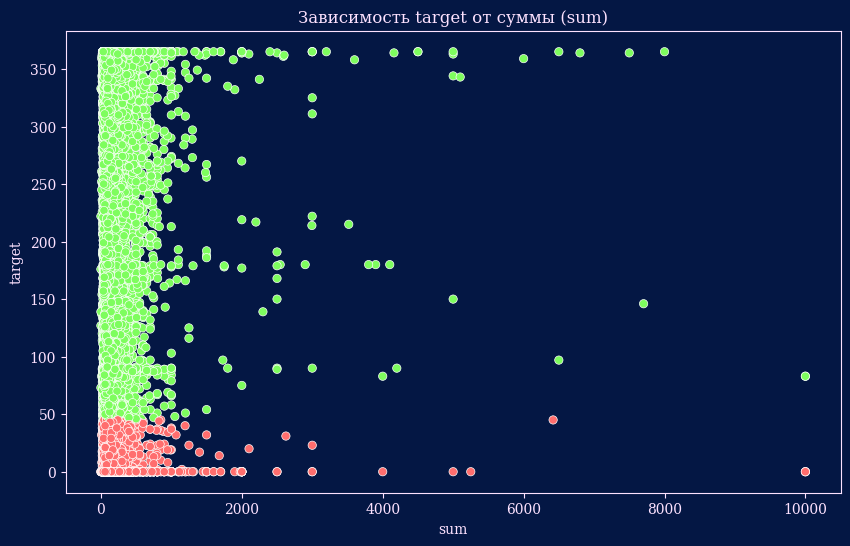

In [ ]:

df_train['target_group'] = df_train['target'].apply(lambda x: 1 if x > df_train['target'].median() else 0)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='sum', y='target', hue='target_group', palette=yes_no_colors, legend=False)
plt.title('Зависимость target от суммы (sum)')
plt.xlabel('sum')
plt.ylabel('target')
plt.show()


In [ ]:
df_train.drop(columns=['target_group'], inplace=True, errors='ignore')

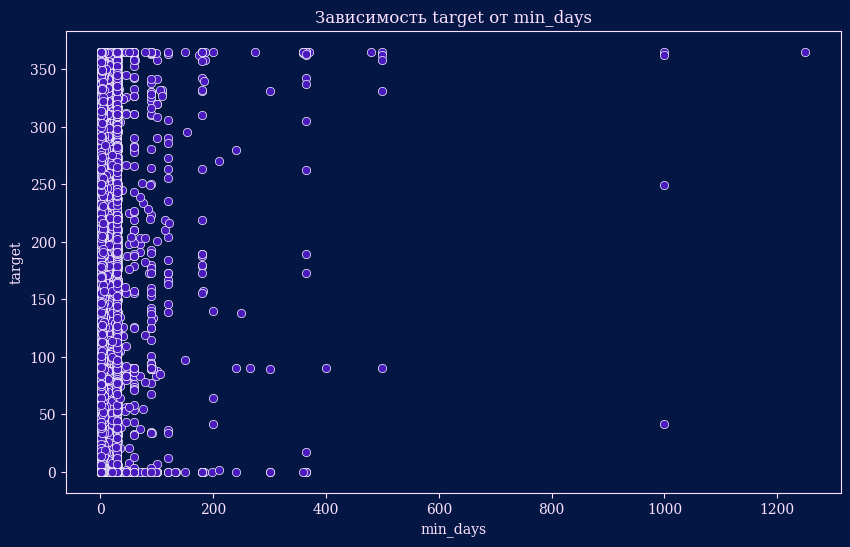

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='min_days', y='target', color=fill_color)
plt.title('Зависимость target от min_days')
plt.xlabel('min_days')
plt.ylabel('target')
plt.show()

### Отскейлим некоторые

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_train[['sum', 'min_days', 'amt_reviews', 'avg_reviews']] = scaler.fit_transform(
    df_train[['sum', 'min_days', 'amt_reviews', 'avg_reviews']]
)


df_test[['sum', 'min_days', 'amt_reviews', 'avg_reviews',]] = scaler.fit_transform(
    df_test[['sum', 'min_days', 'amt_reviews', 'avg_reviews']]
)

In [ ]:
df_train_new = df_train.copy()
df_test_new = df_test.copy()

# Обучаем модели

### катубост

In [ ]:
!pip install catboost -U numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 73.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [ ]:
!pip uninstall catboost

Found existing installation: catboost 1.2.7
Uninstalling catboost-1.2.7:
  Would remove:
    /usr/local/etc/jupyter/nbconfig/notebook.d/catboost-widget.json
    /usr/local/lib/python3.11/dist-packages/catboost-1.2.7.dist-info/*
    /usr/local/lib/python3.11/dist-packages/catboost/*
    /usr/local/share/jupyter/labextensions/catboost-widget/package.json
    /usr/local/share/jupyter/labextensions/catboost-widget/static/138.1b18795f1631648f3df1.js
    /usr/local/share/jupyter/labextensions/catboost-widget/static/479.d43617224b25ecf15b1d.js
    /usr/local/share/jupyter/labextensions/catboost-widget/static/479.d43617224b25ecf15b1d.js.LICENSE.txt
    /usr/local/share/jupyter/labextensions/catboost-widget/static/486.bafd26b008c3405f7750.js
    /usr/local/share/jupyter/labextensions/catboost-widget/static/486.bafd26b008c3405f7750.js.LICENSE.txt
    /usr/local/share/jupyter/labextensions/catboost-widget/static/755.297bcad6e07632169fc2.js
    /usr/local/share/jupyter/labextensions/catboost-widge

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error

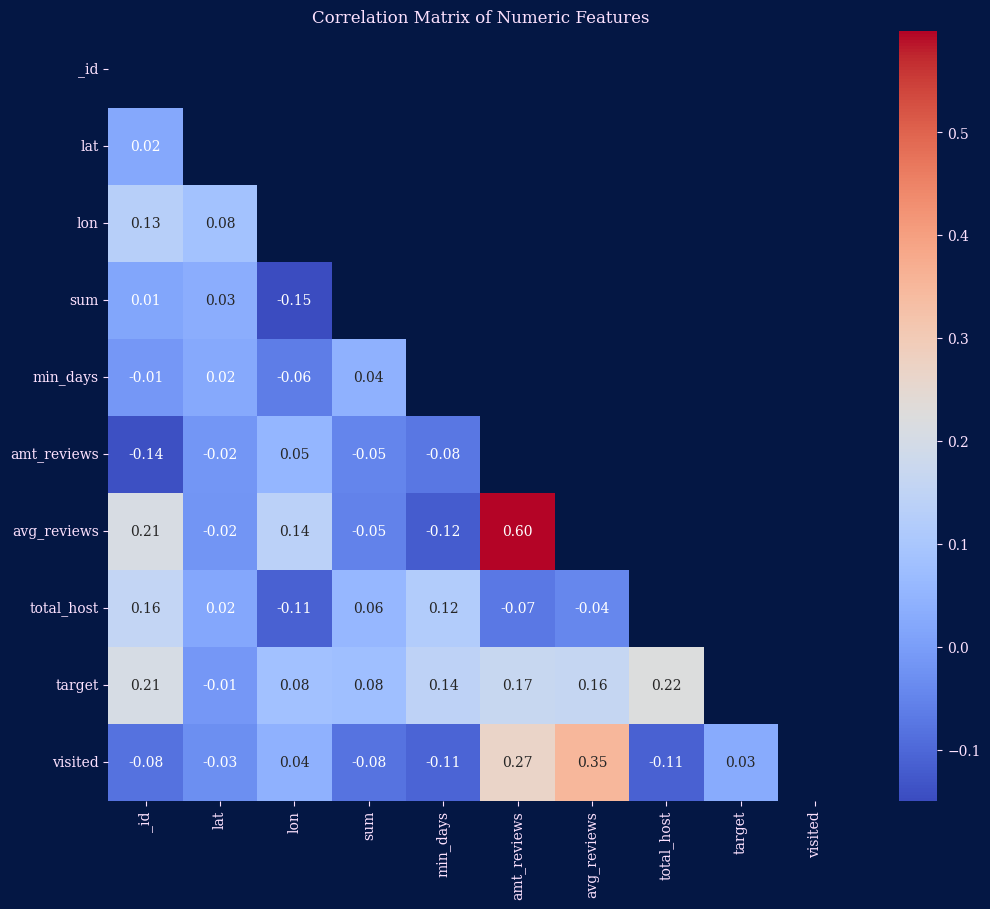

In [ ]:
df_train_copy = df_train.copy()
numerical_columns = df_train_copy.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_train_copy[numerical_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True,
            cmap='coolwarm', fmt=".2f", mask = np.triu(correlation_matrix))
plt.title('Correlation Matrix of Numeric Features')
plt.show()


In [ ]:
cats = ['location', 'location_cluster', 'type_house', 'host_name']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_train.drop(columns=['target']), df_train['target'], test_size=0.2, random_state=42)


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36671 entries, 0 to 36670
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               36671 non-null  int64  
 1   host_name         36671 non-null  object 
 2   location_cluster  36671 non-null  object 
 3   location          36671 non-null  object 
 4   lat               36671 non-null  float64
 5   lon               36671 non-null  float64
 6   type_house        36671 non-null  object 
 7   sum               36671 non-null  float64
 8   min_days          36671 non-null  float64
 9   amt_reviews       36671 non-null  float64
 10  avg_reviews       36671 non-null  float64
 11  total_host        36671 non-null  int64  
 12  target            36671 non-null  int64  
 13  visited           36671 non-null  int64  
dtypes: float64(6), int64(4), object(4)
memory usage: 3.9+ MB


In [ ]:
train_data = Pool(data=X_train, label=y_train, cat_features=cats)
test_data = Pool(data=X_test, label=y_test, cat_features=cats)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 14.1 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.metrics import mean_squared_error

In [ ]:
def objective(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 1000, 3000),
        'depth': trial.suggest_int('depth', 4, 6),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.01),
        'verbose': 200,
    }

    model = CatBoostRegressor(**param)
    model.fit(train_data, verbose=200)
    y_pred = model.predict(test_data)

    mse = mean_squared_error(y_test, y_pred)

    return mse

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=3)



[I 2025-03-27 17:44:28,444] A new study created in memory with name: no-name-7a1877bc-89d1-4974-9f00-e78aeb95fcc7


0:	learn: 131.0401839	total: 59.7ms	remaining: 2m 56s
200:	learn: 109.3498425	total: 13.7s	remaining: 3m 7s
400:	learn: 105.7392690	total: 25.6s	remaining: 2m 43s
600:	learn: 104.1618340	total: 32s	remaining: 2m 5s
800:	learn: 103.2375387	total: 38.6s	remaining: 1m 44s
1000:	learn: 102.5561902	total: 43.5s	remaining: 1m 25s
1200:	learn: 101.9755102	total: 49.8s	remaining: 1m 12s
1400:	learn: 101.4260960	total: 54.7s	remaining: 1m
1600:	learn: 100.8960398	total: 1m 1s	remaining: 51.8s
1800:	learn: 100.4704409	total: 1m 5s	remaining: 42.4s
2000:	learn: 100.1085139	total: 1m 10s	remaining: 33.8s
2200:	learn: 99.8090060	total: 1m 16s	remaining: 26.5s
2400:	learn: 99.5337833	total: 1m 21s	remaining: 19s
2600:	learn: 99.2825158	total: 1m 27s	remaining: 12.1s
2800:	learn: 99.0408060	total: 1m 32s	remaining: 5.27s
2960:	learn: 98.8649939	total: 1m 35s	remaining: 0us


[I 2025-03-27 17:46:05,523] Trial 0 finished with value: 10425.20365908962 and parameters: {'iterations': 2961, 'depth': 5, 'learning_rate': 0.008504709245081165}. Best is trial 0 with value: 10425.20365908962.


0:	learn: 131.0627548	total: 21.8ms	remaining: 56.7s
200:	learn: 110.7475749	total: 5.27s	remaining: 1m 2s
400:	learn: 106.9966777	total: 8.73s	remaining: 48s
600:	learn: 105.3980310	total: 12.4s	remaining: 41.4s
800:	learn: 104.4337992	total: 18.8s	remaining: 42.3s
1000:	learn: 103.7404435	total: 22.5s	remaining: 36s
1200:	learn: 103.1917119	total: 26.8s	remaining: 31.3s
1400:	learn: 102.6959612	total: 31.6s	remaining: 27.2s
1600:	learn: 102.2452334	total: 35.4s	remaining: 22.2s
1800:	learn: 101.8341646	total: 39.5s	remaining: 17.6s
2000:	learn: 101.5000542	total: 44.3s	remaining: 13.3s
2200:	learn: 101.2276940	total: 47.9s	remaining: 8.78s
2400:	learn: 101.0010566	total: 51.7s	remaining: 4.37s
2600:	learn: 100.7855457	total: 56.8s	remaining: 65.5ms
2603:	learn: 100.7831165	total: 56.8s	remaining: 0us


[I 2025-03-27 17:47:03,077] Trial 1 finished with value: 10584.318752593159 and parameters: {'iterations': 2604, 'depth': 4, 'learning_rate': 0.008033984910424343}. Best is trial 0 with value: 10425.20365908962.


0:	learn: 131.0911838	total: 26.1ms	remaining: 51.7s
200:	learn: 110.7299175	total: 4.87s	remaining: 43.1s
400:	learn: 106.5888556	total: 10.8s	remaining: 42.6s
600:	learn: 104.8195081	total: 15.6s	remaining: 35.7s
800:	learn: 103.8206040	total: 20.8s	remaining: 30.6s
1000:	learn: 103.1438750	total: 26.6s	remaining: 26s
1200:	learn: 102.5960071	total: 31.6s	remaining: 20.4s
1400:	learn: 102.1222813	total: 37.8s	remaining: 15.6s
1600:	learn: 101.6620488	total: 42.6s	remaining: 10.1s
1800:	learn: 101.1984546	total: 48.9s	remaining: 4.84s
1978:	learn: 100.8391520	total: 53.3s	remaining: 0us


[I 2025-03-27 17:47:57,167] Trial 2 finished with value: 10611.618524574209 and parameters: {'iterations': 1979, 'depth': 5, 'learning_rate': 0.006997489441748851}. Best is trial 0 with value: 10425.20365908962.


In [ ]:
# Лучшие параметры
print("Best trial:")
trial = study.best_trial
print(f"  MSE: {trial.value}")
print(f"  Best Parameters: {trial.params}")

Best trial:
  MSE: 10425.20365908962
  Best Parameters: {'iterations': 2961, 'depth': 5, 'learning_rate': 0.008504709245081165}


In [ ]:
model = CatBoostRegressor(
    iterations=1750,
    depth=5,
    learning_rate=0.037,
    max_bin = 250,
    loss_function='RMSE',
    verbose=200
)

In [ ]:
model.fit(train_data)

0:	learn: 130.0868285	total: 26ms	remaining: 45.5s
200:	learn: 103.0184458	total: 4.74s	remaining: 36.5s
400:	learn: 100.5931269	total: 10.4s	remaining: 35s
600:	learn: 99.1865881	total: 15.6s	remaining: 29.9s
800:	learn: 98.2885950	total: 20.3s	remaining: 24s
1000:	learn: 97.5143210	total: 26.3s	remaining: 19.6s
1200:	learn: 96.7639679	total: 30.9s	remaining: 14.1s
1400:	learn: 96.1370520	total: 36.8s	remaining: 9.16s
1600:	learn: 95.5601549	total: 41.4s	remaining: 3.85s
1749:	learn: 95.1502226	total: 44.8s	remaining: 0us


In [ ]:
y_pred = model.predict(test_data)

In [ ]:
mse = mean_squared_error(y_pred, y_test)

print("Среднеквадратичная ошибка (MSE):", mse)

Среднеквадратичная ошибка (MSE): 10222.09174091972


# Отправляем решения

In [ ]:
pred = Pool(data=df_test,cat_features=cats)


In [ ]:
y_pred_test = model.predict(pred)

In [ ]:
submission = pd.read_csv('sample_submition.csv')
submission['prediction'] = y_pred_test
submission.to_csv('submission10.csv', index=False)

# Outro
Идеи по улучшению:
1. Попробовать провести более умный feature engeneering
2. Попробовать стекинг нескольких моделей
3. Попробовать сделать регрессию в несколько этапов (сначала предсказать промежуточную фичу, а потом таргет)


я приболела, поэтому вторая сорева вышла похуже чем первая по качеству подхода, не хватило здоровья